In [1]:
import os
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from neo4j import GraphDatabase
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import re

In [2]:
df_final=pd.read_csv("../data/processed/relations_extraction.csv")

In [3]:
df_final.head()

,doc_id,subject,subject_type,relation,object,object_type,evidence_text,confidence,extraction_method,source
0,0,TICKET,TICKET,escalated_to,Mistie,TEAM,"You're welcome, Mistie. I apologize again for ...",0.75,ner,talkmap
1,4,TICKET,TICKET,escalated_to,Union Mobile,TEAM,"You're welcome, Lessie. Thank you for choosing...",0.75,ner,talkmap
2,5,ISSUE,ISSUE,occurred_on,the last,DATE,I completely understand. Let me see if I can h...,0.90,ner,talkmap
3,5,TICKET,TICKET,escalated_to,PIN,TEAM,I completely understand. Let me see if I can h...,0.75,ner,talkmap
4,7,TICKET,TICKET,escalated_to,Union Mobile,TEAM,You're welcome! Thank you for choosing Union M...,0.75,ner,talkmap


In [4]:
df_final.shape

(98041, 10)

In [5]:
sampled_df = df_final.sample(n=500, random_state=42)

In [6]:
sampled_df.head()

,doc_id,subject,subject_type,relation,object,object_type,evidence_text,confidence,extraction_method,source
7418,10080,TICKET,TICKET,escalated_to,Union Mobile,TEAM,"Hello, thank you for calling Union Mobile. My ...",0.75,ner,talkmap
38146,52513,ISSUE,ISSUE,located_at,Wi-Fi,LOCATION,"Yes, I'm having some trouble using Wi-Fi calli...",0.85,ner,talkmap
35487,48995,TICKET,TICKET,escalated_to,Union Mobile,TEAM,"You're welcome, Cordia. Thank you for choosing...",0.75,ner,talkmap
21700,29917,ACCOUNT,ACCOUNT,has_billing_amount,500,MONEY,"Yes, it happened yesterday, and it was for $50...",0.85,ner,talkmap
40340,55466,ISSUE,ISSUE,occurred_on,today,DATE,"Wonderful, I'll set that up for you right away...",0.90,ner,talkmap


In [7]:
sampled_df.shape

(500, 10)

In [ ]:
os.environ["NEO4J_URI"] = "*****"
os.environ["NEO4J_USERNAME"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "*****"
os.environ["NEO4J_DATABASE"] = "neo4j"

In [9]:
uri = os.environ["NEO4J_URI"]
user = os.environ["NEO4J_USERNAME"]
password = os.environ["NEO4J_PASSWORD"]

In [10]:
driver = GraphDatabase.driver(uri, auth=(user, password))
with driver.session(database=os.environ["NEO4J_DATABASE"]) as session:
    print(session.run("RETURN 'Connected to Neo4j Aura!' AS status").single()["status"])

Connected to Neo4j Aura!


In [11]:
sampled_df = sampled_df.dropna(subset=['subject', 'object', 'relation'])

In [12]:
sampled_df['relation'] = sampled_df['relation'].str.upper()

In [13]:
def create_graph(tx, subject, subject_type, relation, obj, object_type, evidence_text):
    cypher = f"""
    MERGE (s:{subject_type} {{name: $subject}})
    MERGE (o:{object_type} {{name: $object}})
    MERGE (s)-[r:{relation} {{evidence_text: $evidence_text}}]->(o)
    """
    tx.run(cypher,
           subject=subject,
           object=obj,
           evidence_text=evidence_text,
           )


In [14]:
#with driver.session() as session:
#    for _, row in sampled_df.iterrows():
#       session.execute_write(
#            create_graph,
#            row['subject'],
#            row['subject_type'],
#            row['relation'],
#            row['object'],
#            row['object_type'],
#            row['evidence_text'],
#        )


In [15]:
query = """
MATCH (s)-[r]->(o)
RETURN s.name AS source, type(r) AS relation, o.name AS target
"""

In [16]:
edges = []
with driver.session() as session:
    results = session.run(query)
    for record in results:
        edges.append((record["source"], record["target"], {"label": record["relation"]}))

In [17]:
G = nx.DiGraph()  
G.add_edges_from(edges)

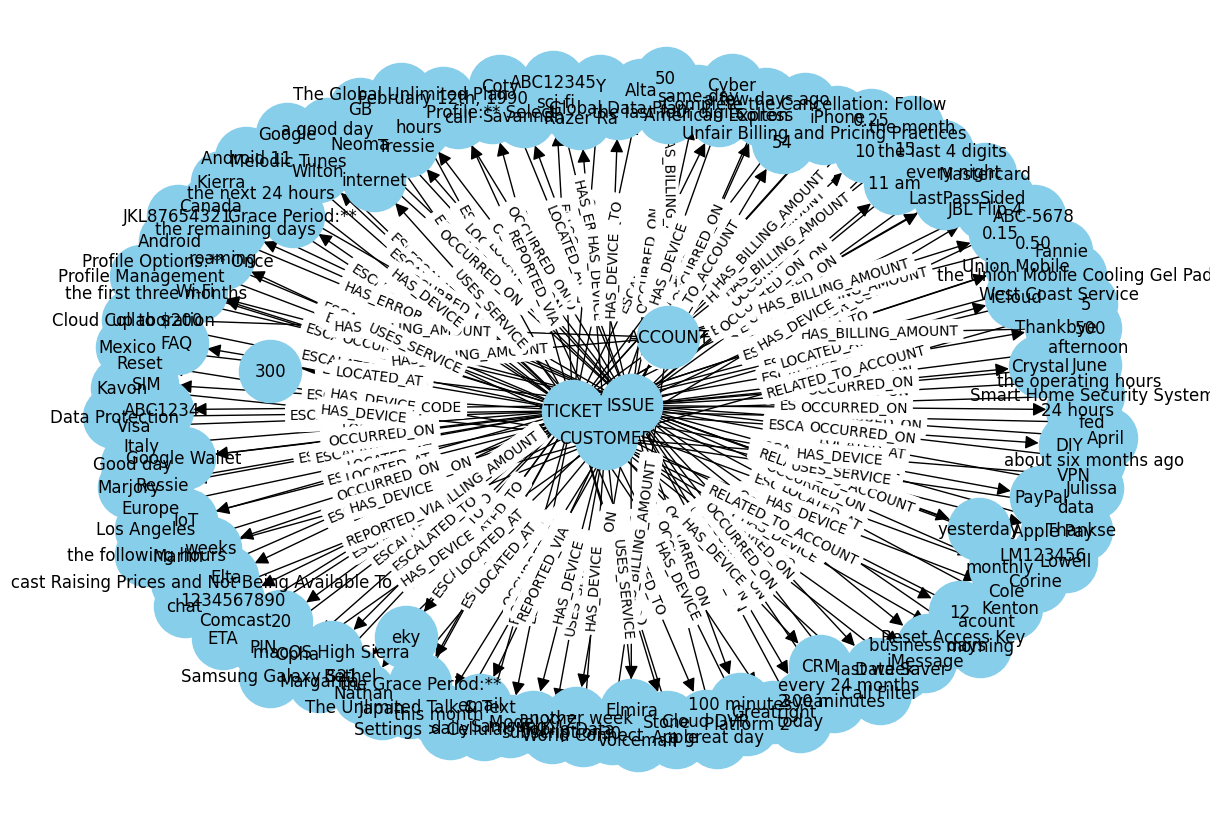

In [18]:
pos = nx.spring_layout(G, k=0.5, seed=42)  # Layout
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=2000, arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

In [19]:
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational", 
    provider="auto",
    max_new_tokens=512,
    temperature=0.6,
)
chat = ChatHuggingFace(llm=llm, verbose=True)

In [20]:
sampled_df['relation'].unique()

array(['ESCALATED_TO', 'LOCATED_AT', 'HAS_BILLING_AMOUNT', 'OCCURRED_ON',
       'REPORTED_VIA', 'USES_SERVICE', 'HAS_DEVICE', 'HAS_ERROR_CODE',
       'RELATED_TO_ACCOUNT'], dtype=object)

In [50]:
RELATION_MAP = {
    "ESCALATED_TO": ["who", "escalated", "handled"],
    "LOCATED_AT": ["where", "located", "location"],
    "HAS_DEVICE": ["device", "phone", "router"],
    "HAS_BILLING_AMOUNT": ["billing", "amount", "cost"],
    "OCCURRED_ON": ["when", "date", "occurred"],
    "REPORTED_VIA": ["reported", "via", "channel"],
    "HAS_ERROR_CODE": ["error", "code"],
    "RELATED_TO_ACCOUNT": ["account", "customer"]
}


In [66]:
STOPWORDS = {
    "the","is","a","an","and","or","to","of","for","on","in",
    "who","what","when","where","why","how","with","are","was"
}

def tokenize(text):
    return {t for t in re.findall(r"\b\w+\b", text.lower()) if t not in STOPWORDS}

def evidence_ok(question, evidence):
    if not evidence:
        return False
    q_tokens = tokenize(question)
    e_tokens = tokenize(evidence)
    min_overlap = min(5, max(2, len(q_tokens)//2))
    return len(q_tokens & e_tokens) >= min_overlap

In [67]:
def is_aggregation_question(q):
    keywords = ["most", "frequently", "often", "common", "majority"]
    return any(k in q.lower() for k in keywords)

def detect_relation(question):
    q = question.lower()
    for rel, keywords in RELATION_MAP.items():
        if any(k in q for k in keywords):
            return rel
    return None

In [68]:
def query_graph(question, driver, top_k=10):
    relation = detect_relation(question)
    if not relation:
        cypher = f"""
        MATCH (s)-[r]->(o)
        RETURN s.name AS subject, type(r) AS relation, o.name AS object, r.evidence_text AS evidence
        LIMIT {top_k}
        """
    else:
        cypher = f"""
        MATCH (s)-[r:{relation}]->(o)
        RETURN s.name AS subject, type(r) AS relation, o.name AS object, r.evidence_text AS evidence
        LIMIT {top_k}
        """
    with driver.session() as session:
        results = session.run(cypher).data()

    filtered = [f for f in results if evidence_ok(question, f.get("evidence"))]
    if not filtered:
        filtered = results[:3]

    return filtered

In [70]:
def query_device_frequency(driver, top_k=5):
    cypher = f"""
    MATCH (s)-[:HAS_DEVICE]->(d)
    RETURN d.name AS device, COUNT(*) AS freq
    ORDER BY freq DESC
    LIMIT {top_k}
    """
    with driver.session() as session:
        return session.run(cypher).data()

In [ ]:
def query_kg_debug(question):
    q = question.lower()
    relation = None

    for rel, keywords in RELATION_MAP.items():
        if any(k in q for k in keywords):
            relation = rel
            break

    if relation:
        cypher = f"""
        MATCH (s)-[r:{relation}]->(o)
        RETURN 
            s.name AS subject,
            type(r) AS relation,
            o.name AS object,
            r.evidence_text AS evidence
        LIMIT 10
        """
    else:
        cypher = """
        MATCH (s)-[r]->(o)
        RETURN 
            s.name AS subject,
            type(r) AS relation,
            o.name AS object,
            r.evidence_text AS evidence
        LIMIT 10
        """

    with driver.session() as session:
        results = session.run(cypher).data()

    print("=== RAW RESULTS FROM NEO4J ===")
    for r in results:
        print(r)

    return results


In [65]:
facts = query_kg_debug(
    "with what device are issues most frequently reported?"
)


=== RAW RESULTS FROM NEO4J ===
{'subject': 'CUSTOMER', 'relation': 'HAS_DEVICE', 'object': 'Samsung Galaxy S21', 'evidence': "I'm using a Samsung Galaxy S21."}
{'subject': 'CUSTOMER', 'relation': 'HAS_DEVICE', 'object': 'Samsung Galaxy S21', 'evidence': "Yeah, I've tried everything. I'm using a Samsung Galaxy S21 and I'm trying to watch a show on Netflix. I've also tried other streaming services and it's still not working."}
{'subject': 'CUSTOMER', 'relation': 'HAS_DEVICE', 'object': 'Samsung Galaxy S21', 'evidence': "I'm using a Samsung Galaxy S21 and I'm currently in Berlin, Germany."}
{'subject': 'CUSTOMER', 'relation': 'HAS_DEVICE', 'object': 'VPN', 'evidence': "Hi Chandra, I'm having some trouble with my VPN account. I'm having trouble setting it up and managing it."}
{'subject': 'CUSTOMER', 'relation': 'HAS_DEVICE', 'object': 'VPN', 'evidence': 'I understand. Have you tried restarting the VPN software or troubleshooting any network issues on your end?'}
{'subject': 'CUSTOMER', 'r

In [69]:
def kg_rag_answer(question, facts, chat_model):
    if not facts:
        return "I couldn't find sufficiently grounded evidence in the graph."

    context = "\n".join(
        f"{f.get('subject', f.get('device'))} -[{f.get('relation','')}] -> {f.get('object', f.get('device'))}\nEvidence: {f.get('evidence','')}"
        for f in facts
    )

    prompt = f"""
You are a customer support assistant.
Answer ONLY using the facts below.
If the answer is not clearly present in the facts, say "I don't know."

Facts:
{context}

Question:
{question}

Answer:
"""

    return chat_model.invoke(prompt).content

In [71]:
def graph_rag_chat(question, driver, chat_model, top_k=5):
    if is_aggregation_question(question):
        facts = query_device_frequency(driver, top_k=top_k)
        if not facts:
            return "No device frequency information found in the graph."

        context = "\n".join([f"Device: {f['device']} — Count: {f['freq']}" for f in facts])
        prompt = f"""
You are a customer support analyst.
Answer the question using ONLY the graph statistics below.

Graph Statistics:
{context}

Question:
{question}

Answer:
"""
        return chat_model.invoke(prompt).content

    facts = query_graph(question, driver, top_k=top_k)
    return kg_rag_answer(question, facts, chat_model)

In [72]:
def ask_kg_bot(question, driver, chat_model, top_k=5):
    return graph_rag_chat(question, driver, chat_model, top_k=top_k)


In [73]:
question = "With what device are issues most frequently reported?"
answer = ask_kg_bot(question, driver, chat)
print(answer)


Based on the graph statistics, issues are most frequently reported with the "Samsung Galaxy S21" device, with 3 reported issues.


In [74]:
question2 = "Who handles escalated tickets for Union Mobile?"
print(ask_kg_bot(question2, driver, chat))

Jettie, Paulo, and another person (whose name is not mentioned) handle escalated tickets for Union Mobile.


In [76]:
question3 = "Why are Samsung Galaxy devices reported frequently are they more prone to issues or bad phones?"
print(ask_kg_bot(question3, driver, chat))

Based on the graph statistics, Samsung Galaxy S21 devices are reported frequently but it's not necessarily because they are more prone to issues or bad phones. 

There are 3 reports for Samsung Galaxy S21 which is less than the 3 reports for VPN, suggesting that it's not a significantly higher number of issues. 

It's possible that the Samsung Galaxy S21 devices are simply being used more frequently or are more commonly associated with the issues being reported, but we can't determine the root cause with the given information.


In [77]:
question = "Which team is responsible when tickets are escalated?"
answer = ask_kg_bot(question, driver, chat)
print(answer)

Union Mobile is responsible when tickets are escalated.


In [80]:
question = "What is the billing amount for account 29917?"
answer = ask_kg_bot(question, driver, chat)
print(answer)

I don't know. The facts only mention ACCOUNT -[HAS_BILLING_AMOUNT] -> 500 and ACCOUNT -[HAS_BILLING_AMOUNT] -> 30, but the account number is not provided.


In [81]:
question = "How much billing is associated with recent tickets?"
answer = ask_kg_bot(question, driver, chat)
print(answer)

I don't know. The facts provided only mention one ticket, and it doesn't specify if there are any other tickets.


In [83]:
question = "How are tickets typically reported?"
answer = ask_kg_bot(question, driver, chat)
print(answer)

Tickets are typically reported via email.


In [88]:
question = "Explain how tickets are typically escalated and handled, based on the graph."
answer = ask_kg_bot(question, driver, chat)
print(answer)

Based on the provided facts, it appears that tickets are escalated to Union Mobile and then handled by representatives named Jettie, Paulo, and Cordia. However, the exact steps of escalation and handling are not clearly defined.

It seems that the escalation process is triggered when a ticket is escalated to Union Mobile (as indicated by the "[ESCALATED_TO] -> Union Mobile" phrase). However, the facts do not provide information on what triggers the escalation, how the ticket is routed to Union Mobile, or what specific actions are taken after escalation.

After a ticket is escalated to Union Mobile, it is handled by a representative, as indicated by the evidence where Jettie and Paulo introduce themselves and offer assistance. However, the facts do not provide information on how long the ticket remains with the representative, if any additional escalation or routing occurs, or how the ticket is ultimately resolved.

Therefore, I don't have enough information to provide a detailed explan

In [89]:
question = "What patterns can you find in issue reports and the devices used?"
answer = ask_kg_bot(question, driver, chat)
print(answer)

Based on the given facts, I can identify the following patterns:

1. The customer is using a Samsung Galaxy S21 device in all instances.
2. The customer is experiencing issues with watching shows on various streaming services (including Netflix) across multiple instances.
3. The customer's location does not seem to be related to the issue, as they are experiencing the problem both in Berlin, Germany.
